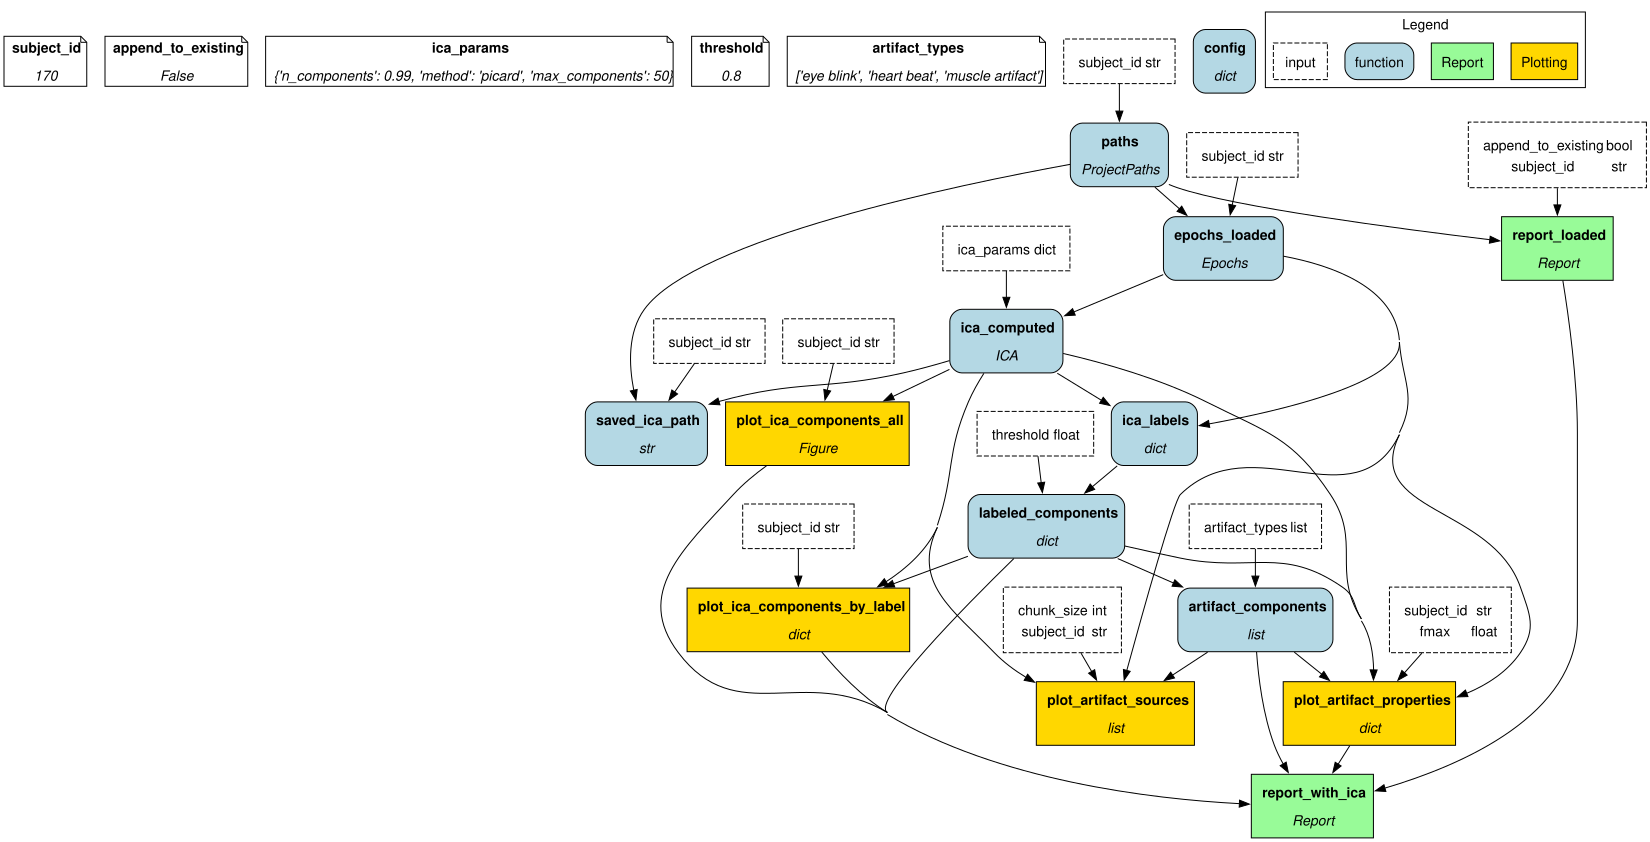

In [1]:
from IPython.display import display
from hamilton import telemetry

from hamilton import driver
from spectral.flows import ica_flow
from spectral.helpers import style_cfg


# Use Builder instead of Driver constructor
dr_ica = (
    driver.Builder()
    .with_config({
        "subject_id": "170",
        "append_to_existing": False,
        "ica_params": {
            "n_components": 0.99,
            "method": "picard",
            "max_components": 50
        },
        "threshold": 0.8,
        "artifact_types": ["eye blink", "heart beat", "muscle artifact"]
    })
    .with_modules(ica_flow)
    .build()
)
dr_ica.display_all_functions(orient="TB", custom_style_function=style_cfg)

Created directories for sub-170
Project root: /Users/daniel/PhD/Projects/psd-paths
Reading /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/epochs/sub-170_good_epochs-epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3000.00 ms
        0 CTF compensation matrices available
Not setting metadata
204 matching events found
No baseline correction applied
0 projection items activated
Fitting ICA to data using 192 channels (please be patient, this may take a while)
Selecting by explained variance: 12 components
Fitting ICA took 4.1s.
ICA computed: 12 components


/Users/daniel/PhD/Projects/psd-paths/src/spectral/spectral/ica.py:39: RuntimeWarning: The provided Epochs instance does not seem to be referenced to a common average reference (CAR). ICLabel was designed to classify features extracted from an EEG dataset referenced to a CAR (see the 'set_eeg_reference()' method for Raw and Epochs instances).
  ic_labels = label_components(eeg_data, ica, method="iclabel")
/Users/daniel/PhD/Projects/psd-paths/src/spectral/spectral/ica.py:39: RuntimeWarning: The provided Epochs instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(eeg_data, ica, method="iclabel")


ICLabel classification complete

Labeled components summary:
  bad_prob_class: [2, 3, 4, 5, 6, 7, 9, 10, 11]
  eye blink: [0]
  brain: [1, 8]


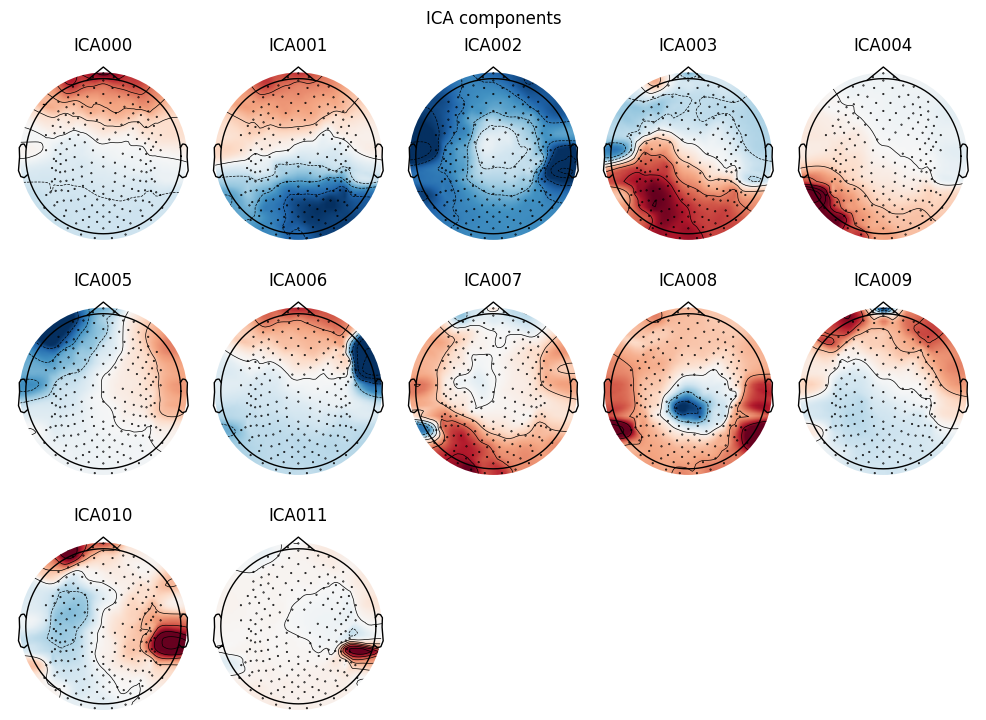

In [2]:
results = dr_ica.execute(  final_vars=["ica_labels", "labeled_components", "plot_ica_components_all"])

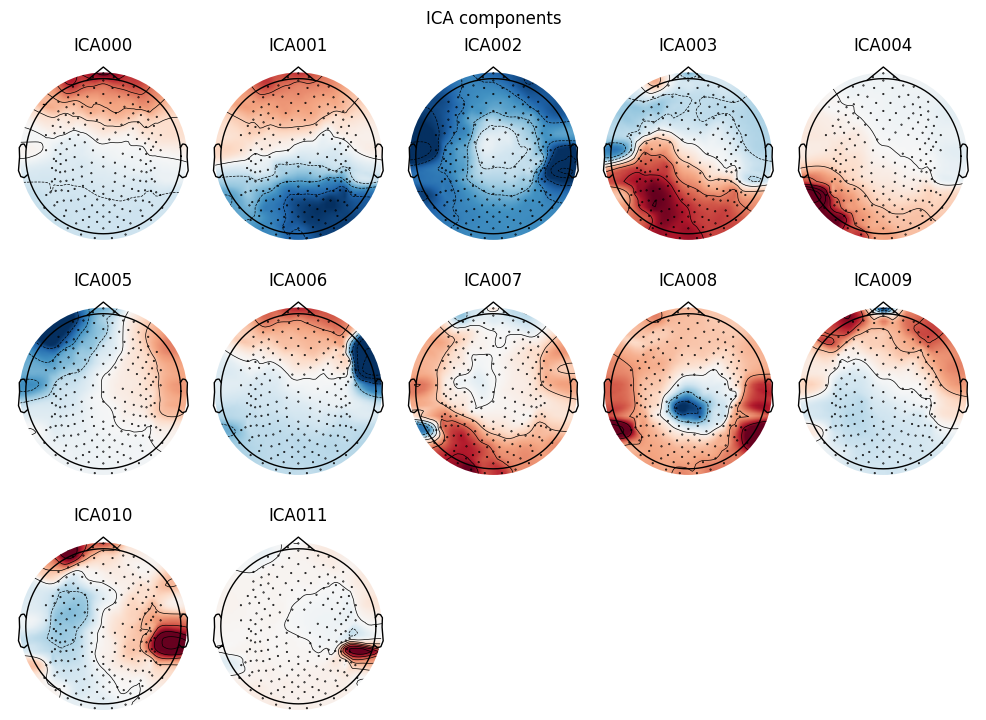

In [4]:
display(results["plot_ica_components_all"])

In [5]:
import hamilton
print(hamilton.__version__)

(1, 89, 0)


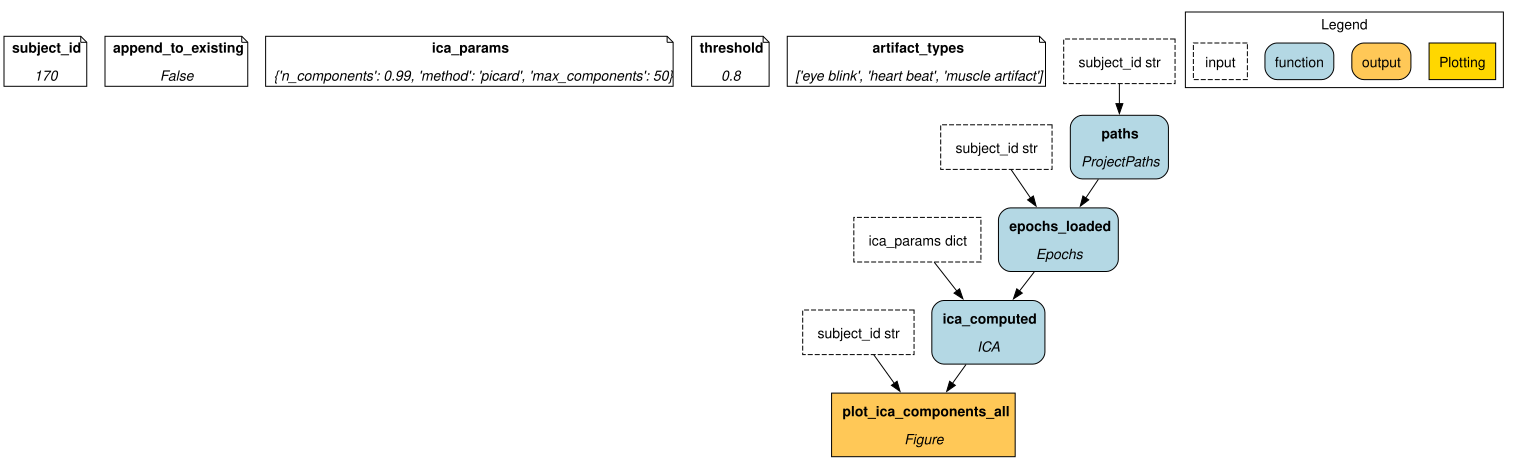

In [6]:
# Use the driver object directly
dot = dr_ica.visualize_execution(
    final_vars=["plot_ica_components_all"],  # Specify the target node(s) here
    orient="TB",
    custom_style_function=style_cfg
)

# If you are in a Jupyter notebook, this will render it:
dot
